<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework2/Problem_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

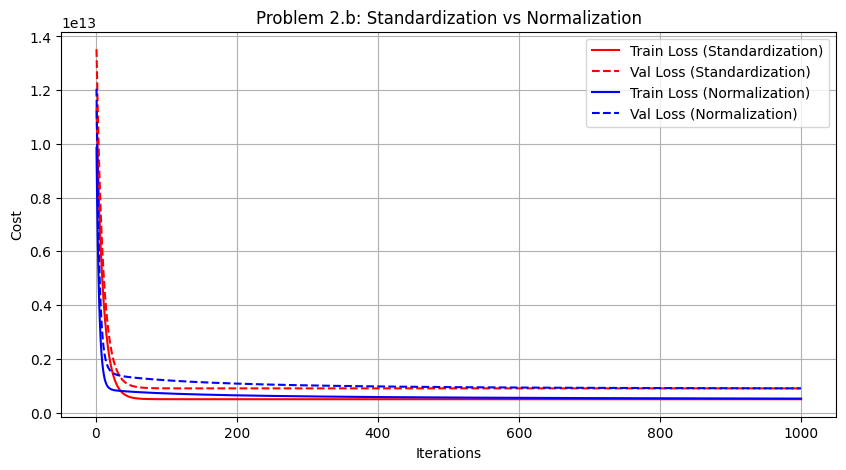

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


np.random.seed(42)


df = pd.read_csv('Housing.csv')


binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
   df[col] = df[col].map({'yes': 1, 'no': 0})


features_2b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']


X = df[features_2b].values
y = df['price'].values.reshape(-1, 1)


X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)


scaler_std = StandardScaler()
X_train_std = np.c_[np.ones((X_train_raw.shape[0], 1)), scaler_std.fit_transform(X_train_raw)]
X_val_std = np.c_[np.ones((X_val_raw.shape[0], 1)), scaler_std.transform(X_val_raw)]


scaler_norm = MinMaxScaler()
X_train_norm = np.c_[np.ones((X_train_raw.shape[0], 1)), scaler_norm.fit_transform(X_train_raw)]
X_val_norm = np.c_[np.ones((X_val_raw.shape[0], 1)), scaler_norm.transform(X_val_raw)]


def compute_cost(X, y, theta):
   m = len(y)
   predictions = X.dot(theta)
   return (1 / (2 * m)) * np.sum(np.square(predictions - y))


def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations):
   m_train = len(y_train)
   train_loss_history = np.zeros(iterations)
   val_loss_history = np.zeros(iterations)

   for i in range(iterations):
       predictions = X_train.dot(theta)
       errors = predictions - y_train
       gradients = (1 / m_train) * X_train.T.dot(errors)
       theta = theta - alpha * gradients

       train_loss_history[i] = compute_cost(X_train, y_train, theta)
       val_loss_history[i] = compute_cost(X_val, y_val, theta)

   return theta, train_loss_history, val_loss_history


alpha = 0.05
iterations = 1000
theta_init = np.zeros((X_train_std.shape[1], 1))


theta_std, train_loss_std, val_loss_std = gradient_descent(X_train_std, y_train, X_val_std, y_val, theta_init, alpha, iterations)
theta_norm, train_loss_norm, val_loss_norm = gradient_descent(X_train_norm, y_train, X_val_norm, y_val, theta_init, alpha, iterations)


plt.figure(figsize=(10, 5))
plt.plot(range(1, iterations + 1), train_loss_std, label='Train Loss (Standardization)', color='red')
plt.plot(range(1, iterations + 1), val_loss_std, label='Val Loss (Standardization)', color='red', linestyle='--')
plt.plot(range(1, iterations + 1), train_loss_norm, label='Train Loss (Normalization)', color='blue')
plt.plot(range(1, iterations + 1), val_loss_norm, label='Val Loss (Normalization)', color='blue', linestyle='--')


plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 2.b: Standardization vs Normalization')
plt.legend()
plt.grid(True)
plt.show()
